In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

import joblib

In [5]:
train_data = pd.read_csv(r"final_train_processed.csv")
test_data = pd.read_csv(r"final_test_processed.csv")

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (12282, 18)
Testing data shape: (1914, 18)


In [6]:
print("Training data:")
print(train_data.head())

print("\nTesting data:")
print(test_data.head())

print("\nTraining columns:")
print(train_data.columns)

Training data:
   CreditScore  Gender       Age    Tenure   Balance  NumOfProducts  \
0    -1.559275       1  2.203528  0.702996  0.334468      -0.772148   
1    -1.887838       1 -1.499687 -0.680357  1.223621      -0.772148   
2    -0.162883       1 -1.605493  1.394672 -1.341260       0.878882   
3    -0.532516       1 -0.653238 -1.717871  0.367751      -0.772148   
4    -0.696798       0 -0.018401 -0.680357  0.460363      -0.772148   

   HasCrCard  IsActiveMember  EstimatedSalary  Geography_Germany  \
0          1               0         1.515320                  1   
1          1               1         0.647485                  0   
2          1               1        -1.606137                  0   
3          0               1        -0.995484                  0   
4          1               1         1.593959                  1   

   Geography_Spain  BalanceSalaryRatio  TenureByAge  BalancePerProduct  \
0                0           -0.031847    -0.195976           0.598022   
1

In [7]:
X_train = train_data.drop("Exited", axis=1)
y_train = train_data["Exited"]

X_test = test_data.drop("Exited", axis=1)
y_test = test_data["Exited"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12282, 17)
y_train shape: (12282,)
X_test shape: (1914, 17)
y_test shape: (1914,)


In [8]:
extra_trees = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print(extra_trees)

ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42)


In [9]:
extra_trees.fit(X_train, y_train)

print("Extra Trees model training completed.")

Extra Trees model training completed.


In [10]:
y_pred = extra_trees.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0]


In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8589341692789969
Accuracy (%): 85.8934169278997


In [12]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1536
           1       0.75      0.43      0.55       378

    accuracy                           0.86      1914
   macro avg       0.81      0.70      0.73      1914
weighted avg       0.85      0.86      0.84      1914



In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1482   54]
 [ 216  162]]


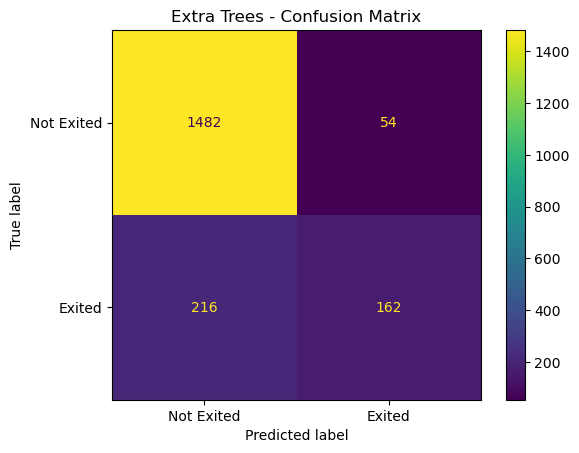

In [14]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Exited", "Exited"]
)

disp.plot()
plt.title("Extra Trees - Confusion Matrix")
plt.show()

In [15]:
y_prob = extra_trees.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8471197434413581


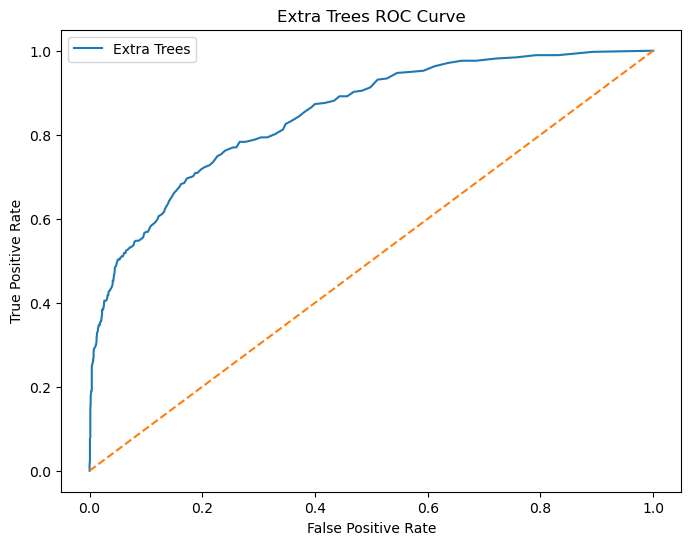

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label="Extra Trees")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Extra Trees ROC Curve")

plt.legend()
plt.show()

In [17]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [33]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [34]:
print("Best Cross-Validation Score:")
print(grid_search.best_score_)

Best Cross-Validation Score:
0.9675143742733321


In [35]:
best_model = grid_search.best_estimator_

print("Best Extra Trees Model:")
print(best_model)

Best Extra Trees Model:
ExtraTreesClassifier(max_depth=30, n_estimators=200, n_jobs=-1, random_state=42)


In [36]:
best_pred = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, best_pred)

print("Test Accuracy:", best_accuracy)
print("Test Accuracy (%):", best_accuracy * 100)

Test Accuracy: 0.8584117032392894
Test Accuracy (%): 85.84117032392894


In [37]:
print("Classification Report:")
print(classification_report(y_test, best_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1536
           1       0.74      0.44      0.55       378

    accuracy                           0.86      1914
   macro avg       0.81      0.70      0.73      1914
weighted avg       0.85      0.86      0.84      1914



In [38]:
best_cm = confusion_matrix(y_test, best_pred)

print("Confusion Matrix:")
print(best_cm)

Confusion Matrix:
[[1478   58]
 [ 213  165]]


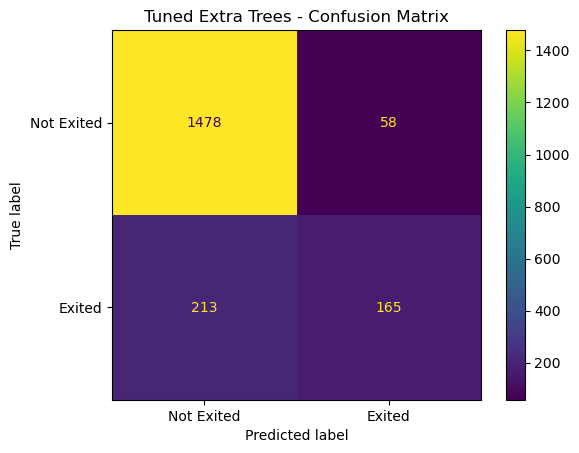

In [39]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=["Not Exited", "Exited"]
)

disp.plot()
plt.title("Tuned Extra Trees - Confusion Matrix")
plt.show()

In [40]:
best_prob = best_model.predict_proba(X_test)[:, 1]

best_roc_auc = roc_auc_score(y_test, best_prob)

print("Tuned Extra Trees ROC-AUC:", best_roc_auc)

Tuned Extra Trees ROC-AUC: 0.8481901730599648


In [41]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
2                  Age    0.181344
5        NumOfProducts    0.131480
12         TenureByAge    0.079529
8      EstimatedSalary    0.077417
0          CreditScore    0.075094
13   BalancePerProduct    0.067628
4              Balance    0.066265
14   ProductsPerTenure    0.060622
3               Tenure    0.056576
11  BalanceSalaryRatio    0.045030
9    Geography_Germany    0.037233
1               Gender    0.025935
7       IsActiveMember    0.024162
10     Geography_Spain    0.020709
6            HasCrCard    0.019288
16       IsZeroBalance    0.017927
15      ActiveWithCard    0.013762


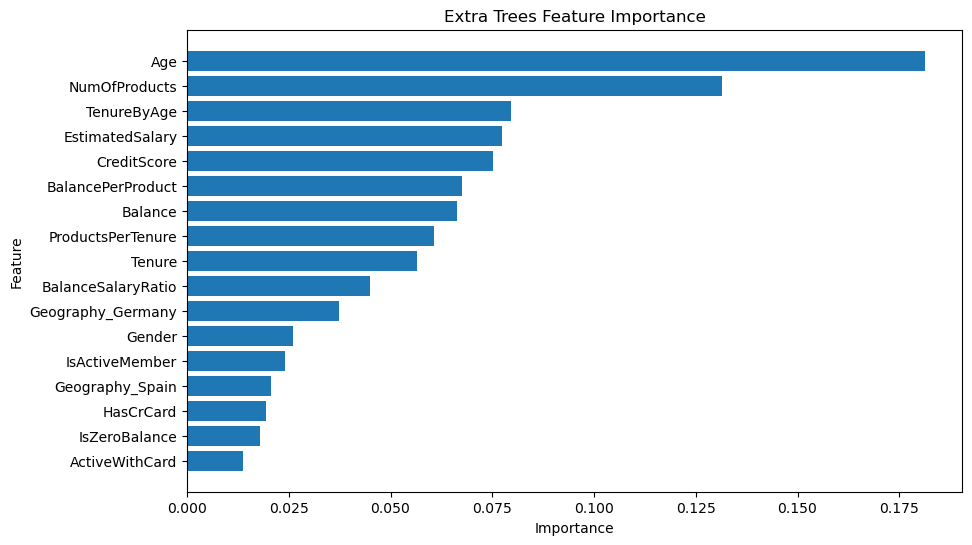

In [42]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Extra Trees Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [43]:
model_path = "extra_trees_model.joblib"

joblib.dump(best_model, model_path)

print("Model saved successfully.")
print("File:", model_path)

Model saved successfully.
File: extra_trees_model.joblib


In [44]:
loaded_model = joblib.load("extra_trees_model.joblib")

print("Model loaded successfully.")

Model loaded successfully.


In [45]:
loaded_predictions = loaded_model.predict(X_test)

loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("Loaded Model Accuracy:", loaded_accuracy)

Loaded Model Accuracy: 0.8584117032392894


In [46]:
results = test_data.copy()

results["Predicted_Exited"] = best_pred

results.to_csv(
    "extra_trees_predictions.csv",
    index=False
)

print("Predictions saved successfully.")

Predictions saved successfully.
